# POS Tagging with Transformer and BiLSTM

This notebook compares two sequence labeling models for POS tagging:

- a Transformer-based model
- a Bidirectional LSTM baseline

We will:
1. load and preprocess the data,
2. define the model architectures,
3. train both models,
4. compare their performance,
5. inspect predictions and attention,
6. visualize results with plots and a confusion matrix.

### Imports

In [1]:
# Install all required dependencies
%pip install --upgrade pip
%pip install tensorflow numpy scikit-learn seaborn matplotlib nltk conllu "datasets<4.0.0"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score
from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt

from data.dataset import load_ud

I0000 00:00:1773696992.616964   42702 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773696992.650860   42702 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773696993.554863   42702 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/dan-gavriluta/Coding/ml-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data preparation

We convert the encoded dataset into padded NumPy arrays so it can be used directly with Keras.

In [3]:
def prepare_for_keras(encoded_list, maxlen):
    """Turns the list of Encoding dataclasses into clean NumPy matrices."""
    word_ids = [e.word_ids for e in encoded_list]
    tag_ids = [e.tag_ids for e in encoded_list]
    
    # We pad with 0 (which matches our <PAD> token)
    X = pad_sequences(word_ids, maxlen=maxlen, padding='post', value=0)
    y = pad_sequences(tag_ids, maxlen=maxlen, padding='post', value=0)
    return np.array(X), np.array(y)

## Transformer components

We define:
- token + position embeddings,
- a Transformer block with multi-head attention,
- feed-forward layers,
- residual connections and normalization.

In [4]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            mask_zero=True
        )
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        # Attention + Residual + Norm
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        # FFN + Residual + Norm
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

## Model builder

This function creates either:
- a Transformer model, or
- a BiLSTM model

using the same configuration dictionary.

In [5]:
def build_model(model_type, config):
    inputs = layers.Input(shape=(config['maxlen'],))

    if model_type == "transformer":
        x = TokenAndPositionEmbedding(
            config['maxlen'],
            config['vocab_size'],
            config['embed_dim']
        )(inputs)
        for _ in range(config.get('num_layers', 1)):
            x = TransformerBlock(
                config['embed_dim'],
                config['num_heads'],
                config['ff_dim']
            )(x)

    elif model_type == "lstm":
        x = layers.Embedding(
            config['vocab_size'],
            config['embed_dim'],
            mask_zero=True
        )(inputs)
        x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

    outputs = layers.Dense(config['num_tags'], activation="softmax")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(config['lr']),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

## Visualization and evaluation helpers

These functions help inspect:
- training history,
- single predictions,
- confusion matrix,
- attention maps,
- comparison between Transformer and BiLSTM.

In [6]:
def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'Accuracy for {title}')
    plt.legend()
    plt.show()

def predict_example(model, vocab, raw_sentences, encoded_data, maxlen, index=0):
    tokens, true_tags = raw_sentences[index]
    input_padded = pad_sequences([encoded_data[index].word_ids], maxlen=maxlen, padding='post')

    preds = model.predict(input_padded)
    pred_indices = np.argmax(preds[0], axis=-1)[:len(tokens)]
    pred_tags = [vocab.id2tag[idx] for idx in pred_indices]

    print(f"\nExample Sentence: {' '.join(tokens)}")
    print(f"{'WORD':<15} | {'TRUE':<10} | {'PRED'}")
    print("-" * 40)
    for w, t, p in zip(tokens, true_tags, pred_tags):
        print(f"{w:<15} | {t:<10} | {p} {'✅' if t == p else '❌'}")

def plot_confusion_matrix(model, X_test, y_test, vocab):
    preds = model.predict(X_test)
    y_pred = np.argmax(preds, axis=-1).flatten()
    y_true = y_test.flatten()

    mask = y_true != 0
    y_true_filtered = y_true[mask]
    y_pred_filtered = y_pred[mask]

    cm = confusion_matrix(y_true_filtered, y_pred_filtered)
    tag_names = vocab.id2tag

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=tag_names, yticklabels=tag_names, cmap="Blues")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('POS Tag Confusion Matrix')
    plt.show()

def plot_attention_map(model, vocab, raw_sentences, encoded_data, maxlen, index=0):
    tokens, _ = raw_sentences[index]
    input_padded = pad_sequences([encoded_data[index].word_ids], maxlen=maxlen, padding='post')

    attn_layer = model.layers[2]  # Adjust index based on model.summary()

    _, weights = attn_layer.att(
        model.layers[1](input_padded),
        model.layers[1](input_padded),
        return_attention_scores=True
    )

    avg_weights = np.mean(weights[0], axis=0)[:len(tokens), :len(tokens)]

    plt.figure(figsize=(8, 6))
    sns.heatmap(avg_weights, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.title(f"Attention Map: {' '.join(tokens)}")
    plt.show()

def compare_histories(trans_history, lstm_history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(trans_history.history['val_accuracy'], label='Transformer Val Acc', color='blue')
    plt.plot(lstm_history.history['val_accuracy'], label='LSTM Val Acc', color='orange', linestyle='--')
    plt.title('Accuracy: Transformer vs LSTM')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(trans_history.history['val_loss'], label='Transformer Val Loss', color='blue')
    plt.plot(lstm_history.history['val_loss'], label='LSTM Val Loss', color='orange', linestyle='--')
    plt.title('Loss: Transformer vs LSTM')
    plt.legend()

    plt.show()

def compare_models_metrics(transformer_model, lstm_model, X, y):
    """
    Computes token-level metrics for Transformer and LSTM models
    and prints them in a simple comparison table.
    """

    # Predictions
    trans_preds = transformer_model.predict(X, verbose=0)
    lstm_preds = lstm_model.predict(X, verbose=0)

    y_true = y.flatten()

    y_pred_trans = np.argmax(trans_preds, axis=-1).flatten()
    y_pred_lstm = np.argmax(lstm_preds, axis=-1).flatten()

    # Remove padding tokens
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred_trans = y_pred_trans[mask]
    y_pred_lstm = y_pred_lstm[mask]

    # Metrics
    acc_trans = accuracy_score(y_true, y_pred_trans)
    acc_lstm = accuracy_score(y_true, y_pred_lstm)

    prec_t, rec_t, f1_t, _ = precision_recall_fscore_support(
        y_true, y_pred_trans, average="weighted"
    )

    prec_l, rec_l, f1_l, _ = precision_recall_fscore_support(
        y_true, y_pred_lstm, average="weighted"
    )

    print("\nModel Comparison")
    print("-" * 50)
    print(f"{'Metric':<12} | {'Transformer':<12} | {'LSTM'}")
    print("-" * 50)
    print(f"{'Accuracy':<12} | {acc_trans:.4f}       | {acc_lstm:.4f}")
    print(f"{'Precision':<12} | {prec_t:.4f}       | {prec_l:.4f}")
    print(f"{'Recall':<12} | {rec_t:.4f}       | {rec_l:.4f}")
    print(f"{'F1 Score':<12} | {f1_t:.4f}       | {f1_l:.4f}")

def compare_tag_accuracy(transformer_model, lstm_model, X, y, vocab):
    """
    Compare per-tag accuracy for Transformer and LSTM models.
    Ignores padding token (ID 0).
    """

    # Predict
    trans_preds = transformer_model.predict(X, verbose=0)
    lstm_preds = lstm_model.predict(X, verbose=0)

    y_true = y.flatten()
    y_pred_trans = np.argmax(trans_preds, axis=-1).flatten()
    y_pred_lstm = np.argmax(lstm_preds, axis=-1).flatten()

    # Remove padding
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred_trans = y_pred_trans[mask]
    y_pred_lstm = y_pred_lstm[mask]

    tag_ids = sorted(set(y_true))

    trans_accs = []
    lstm_accs = []
    tag_names = []

    for tag_id in tag_ids:
        tag_mask = y_true == tag_id

        trans_acc = np.mean(y_pred_trans[tag_mask] == y_true[tag_mask])
        lstm_acc = np.mean(y_pred_lstm[tag_mask] == y_true[tag_mask])

        trans_accs.append(trans_acc)
        lstm_accs.append(lstm_acc)
        tag_names.append(vocab.id2tag[tag_id])

    x = np.arange(len(tag_names))
    width = 0.35

    plt.figure(figsize=(14, 6))
    plt.bar(x - width/2, trans_accs, width, label="Transformer")
    plt.bar(x + width/2, lstm_accs, width, label="LSTM")

    plt.xticks(x, tag_names, rotation=45)
    plt.ylabel("Accuracy")
    plt.xlabel("POS Tag")
    plt.title("Per-Tag Accuracy: Transformer vs LSTM")
    plt.ylim(0, 1.0)
    plt.legend()
    plt.tight_layout()
    plt.show()

def compare_tag_accuracy_sorted(transformer_model, lstm_model, X, y, vocab):
    """
    Compare per-tag accuracy for Transformer and LSTM models,
    sorted by absolute performance difference.
    """

    trans_preds = transformer_model.predict(X, verbose=0)
    lstm_preds = lstm_model.predict(X, verbose=0)

    y_true = y.flatten()
    y_pred_trans = np.argmax(trans_preds, axis=-1).flatten()
    y_pred_lstm = np.argmax(lstm_preds, axis=-1).flatten()

    mask = y_true != 0
    y_true = y_true[mask]
    y_pred_trans = y_pred_trans[mask]
    y_pred_lstm = y_pred_lstm[mask]

    results = []

    for tag_id in sorted(set(y_true)):
        tag_mask = y_true == tag_id

        trans_acc = np.mean(y_pred_trans[tag_mask] == y_true[tag_mask])
        lstm_acc = np.mean(y_pred_lstm[tag_mask] == y_true[tag_mask])

        results.append({
            "tag": vocab.id2tag[tag_id],
            "transformer": trans_acc,
            "lstm": lstm_acc,
            "diff": abs(trans_acc - lstm_acc)
        })

    results.sort(key=lambda x: x["diff"], reverse=True)

    tag_names = [r["tag"] for r in results]
    trans_accs = [r["transformer"] for r in results]
    lstm_accs = [r["lstm"] for r in results]

    x = np.arange(len(tag_names))
    width = 0.35

    plt.figure(figsize=(14, 6))
    plt.bar(x - width/2, trans_accs, width, label="Transformer")
    plt.bar(x + width/2, lstm_accs, width, label="LSTM")

    plt.xticks(x, tag_names, rotation=45)
    plt.ylabel("Accuracy")
    plt.xlabel("POS Tag")
    plt.title("Per-Tag Accuracy Difference: Transformer vs LSTM")
    plt.ylim(0, 1.0)
    plt.legend()
    plt.tight_layout()
    plt.show()

def compare_sentence_accuracy(transformer_model, lstm_model, X, y):
    """
    Compare sentence-level accuracy and show counts of fully correct sentences.
    """

    trans_preds = transformer_model.predict(X, verbose=0)
    lstm_preds = lstm_model.predict(X, verbose=0)

    y_pred_trans = np.argmax(trans_preds, axis=-1)
    y_pred_lstm = np.argmax(lstm_preds, axis=-1)

    trans_correct_sentences = 0
    lstm_correct_sentences = 0
    total_sentences = len(y)

    for i in range(total_sentences):
        true_seq = y[i]
        trans_seq = y_pred_trans[i]
        lstm_seq = y_pred_lstm[i]

        mask = true_seq != 0
        true_seq = true_seq[mask]
        trans_seq = trans_seq[mask]
        lstm_seq = lstm_seq[mask]

        if np.array_equal(true_seq, trans_seq):
            trans_correct_sentences += 1

        if np.array_equal(true_seq, lstm_seq):
            lstm_correct_sentences += 1

    trans_acc = trans_correct_sentences / total_sentences
    lstm_acc = lstm_correct_sentences / total_sentences

    print("\nSentence-Level Accuracy Comparison")
    print("-" * 60)
    print(f"{'Model':<15} | {'Correct Sentences':<20} | {'Accuracy'}")
    print("-" * 60)
    print(f"{'Transformer':<15} | {trans_correct_sentences:<20} | {trans_acc:.4f} ({trans_acc*100:.2f}%)")
    print(f"{'LSTM':<15} | {lstm_correct_sentences:<20} | {lstm_acc:.4f} ({lstm_acc*100:.2f}%)")

def evaluate_models_on_test_set(transformer_model, lstm_model, X_test, y_test, vocab):
    """
    Compare Transformer and LSTM on the same test set.

    Returns:
        - token-level accuracy
        - weighted precision, recall, F1
        - sentence-level accuracy
        - per-tag accuracy
    """

    # Predictions
    trans_preds = transformer_model.predict(X_test, verbose=0)
    lstm_preds = lstm_model.predict(X_test, verbose=0)

    y_pred_trans = np.argmax(trans_preds, axis=-1)
    y_pred_lstm = np.argmax(lstm_preds, axis=-1)

    # ---------------------------
    # Token-level evaluation
    # ---------------------------
    y_true_flat = y_test.flatten()
    y_pred_trans_flat = y_pred_trans.flatten()
    y_pred_lstm_flat = y_pred_lstm.flatten()

    # Ignore padding
    mask = y_true_flat != 0
    y_true_tokens = y_true_flat[mask]
    y_pred_trans_tokens = y_pred_trans_flat[mask]
    y_pred_lstm_tokens = y_pred_lstm_flat[mask]

    # Transformer metrics
    trans_token_acc = accuracy_score(y_true_tokens, y_pred_trans_tokens)
    trans_prec, trans_rec, trans_f1, _ = precision_recall_fscore_support(
        y_true_tokens, y_pred_trans_tokens, average="weighted", zero_division=0
    )

    # LSTM metrics
    lstm_token_acc = accuracy_score(y_true_tokens, y_pred_lstm_tokens)
    lstm_prec, lstm_rec, lstm_f1, _ = precision_recall_fscore_support(
        y_true_tokens, y_pred_lstm_tokens, average="weighted", zero_division=0
    )

    # ---------------------------
    # Sentence-level evaluation
    # ---------------------------
    trans_correct_sentences = 0
    lstm_correct_sentences = 0
    total_sentences = len(y_test)

    for i in range(total_sentences):
        true_seq = y_test[i]
        trans_seq = y_pred_trans[i]
        lstm_seq = y_pred_lstm[i]

        seq_mask = true_seq != 0
        true_seq = true_seq[seq_mask]
        trans_seq = trans_seq[seq_mask]
        lstm_seq = lstm_seq[seq_mask]

        if np.array_equal(true_seq, trans_seq):
            trans_correct_sentences += 1
        if np.array_equal(true_seq, lstm_seq):
            lstm_correct_sentences += 1

    trans_sentence_acc = trans_correct_sentences / total_sentences
    lstm_sentence_acc = lstm_correct_sentences / total_sentences

    # ---------------------------
    # Per-tag accuracy
    # ---------------------------
    per_tag_results = []

    for tag_id in sorted(set(y_true_tokens)):
        tag_mask = y_true_tokens == tag_id

        trans_tag_acc = np.mean(y_pred_trans_tokens[tag_mask] == y_true_tokens[tag_mask])
        lstm_tag_acc = np.mean(y_pred_lstm_tokens[tag_mask] == y_true_tokens[tag_mask])

        per_tag_results.append({
            "tag": vocab.id2tag[tag_id],
            "transformer_acc": trans_tag_acc,
            "lstm_acc": lstm_tag_acc,
            "difference": trans_tag_acc - lstm_tag_acc
        })

    # ---------------------------
    # Print summary
    # ---------------------------
    print("\nOverall Test Set Comparison")
    print("-" * 80)
    print(f"{'Metric':<20} | {'Transformer':<15} | {'LSTM':<15}")
    print("-" * 80)
    print(f"{'Token Accuracy':<20} | {trans_token_acc:<15.4f} | {lstm_token_acc:<15.4f}")
    print(f"{'Precision':<20} | {trans_prec:<15.4f} | {lstm_prec:<15.4f}")
    print(f"{'Recall':<20} | {trans_rec:<15.4f} | {lstm_rec:<15.4f}")
    print(f"{'F1 Score':<20} | {trans_f1:<15.4f} | {lstm_f1:<15.4f}")
    print(f"{'Sentence Accuracy':<20} | {trans_sentence_acc:<15.4f} | {lstm_sentence_acc:<15.4f}")

    print("\nPer-Tag Accuracy")
    print("-" * 80)
    print(f"{'Tag':<12} | {'Transformer':<12} | {'LSTM':<12} | {'Diff (T-L)':<12}")
    print("-" * 80)
    for row in per_tag_results:
        print(
            f"{row['tag']:<12} | "
            f"{row['transformer_acc']:<12.4f} | "
            f"{row['lstm_acc']:<12.4f} | "
            f"{row['difference']:<+12.4f}"
        )

    return {
        "transformer": {
            "token_accuracy": trans_token_acc,
            "precision": trans_prec,
            "recall": trans_rec,
            "f1": trans_f1,
            "sentence_accuracy": trans_sentence_acc,
        },
        "lstm": {
            "token_accuracy": lstm_token_acc,
            "precision": lstm_prec,
            "recall": lstm_rec,
            "f1": lstm_f1,
            "sentence_accuracy": lstm_sentence_acc,
        },
        "per_tag_results": per_tag_results
    }

## Configuration

We define the hyperparameters used throughout the notebook.

In [7]:
MAX_LEN = 30
sentences_to_load = 2000

config = {
    # Architecture & Data Hyperparameters
    "maxlen": MAX_LEN,
    "embed_dim": 128,

    # Transformer-specific
    "num_heads": 4,
    "ff_dim": 128,
    "num_layers": 1,

    # Training
    "lr": 0.001,
    "epochs": 5
}

## Load dataset

We load the Universal Dependencies subset, encode it, and prepare padded input/output tensors.

In [8]:
raw_data, vocab, encoded = load_ud(n=sentences_to_load)
X, y = prepare_for_keras(encoded, MAX_LEN)

X_train, X_test, y_train, y_test, encoded_train, encoded_test, raw_train, raw_test = train_test_split(
    X, y, encoded, raw_data, test_size=0.2, random_state=42
)

config["vocab_size"] = len(vocab.id2word)
config["num_tags"] = len(vocab.id2tag)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Vocab size:", config["vocab_size"])
print("Number of tags:", config["num_tags"])

Generating test split: 100%|██████████| 2077/2077 [00:00<00:00, 4777.79 examples/s]


X shape: (2000, 30)
y shape: (2000, 30)
Vocab size: 6460
Number of tags: 19


## Train Transformer model

In [9]:
transformer_model = build_model("transformer", config)
transformer_model.summary()

E0000 00:00:1773697018.898669   42702 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 30, 128)        │       830,720 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 30, 128)        │       297,344 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30, 19)         │         2,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,130,515 (4.31 MB)

 Trainable params: 1,130,515 (4.31 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
h_trans = transformer_model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=config["epochs"],
    validation_split=0.2
)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7534 - loss: 0.8477 - val_accuracy: 0.8707 - val_loss: 0.4440
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9270 - loss: 0.2475 - val_accuracy: 0.8957 - val_loss: 0.3355
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9546 - loss: 0.1358 - val_accuracy: 0.8994 - val_loss: 0.3314
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9583 - loss: 0.1087 - val_accuracy: 0.9022 - val_loss: 0.3283
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9608 - loss: 0.0973 - val_accuracy: 0.9024 - val_loss: 0.3338


## Train BiLSTM baseline

In [11]:
lstm_model = build_model("lstm", config)
lstm_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 30, 128)   │    826,880 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 30)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 30, 128)   │     98,816 │ embedding_2[0][0… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 19)    │      2,451 │ bidirectional[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 928,147 (3.54 MB)

 Trainable params: 928,147 (3.54 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
h_lstm = lstm_model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=config["epochs"],
    validation_split=0.2
)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2647 - loss: 2.5858 - val_accuracy: 0.3768 - val_loss: 2.2105
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4770 - loss: 1.7948 - val_accuracy: 0.6036 - val_loss: 1.4489
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6916 - loss: 1.1135 - val_accuracy: 0.7267 - val_loss: 0.9470
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8301 - loss: 0.6636 - val_accuracy: 0.8218 - val_loss: 0.6397
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9110 - loss: 0.3855 - val_accuracy: 0.8568 - val_loss: 0.4993


## Compare histories

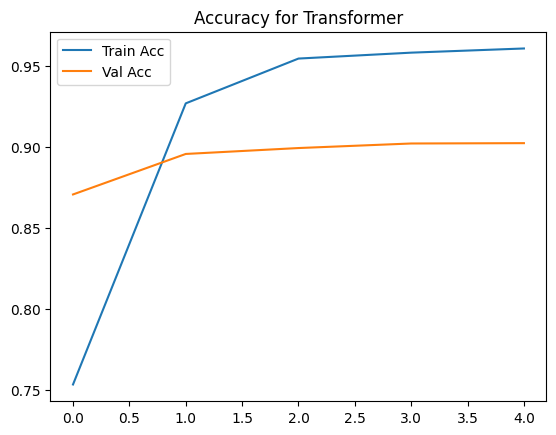

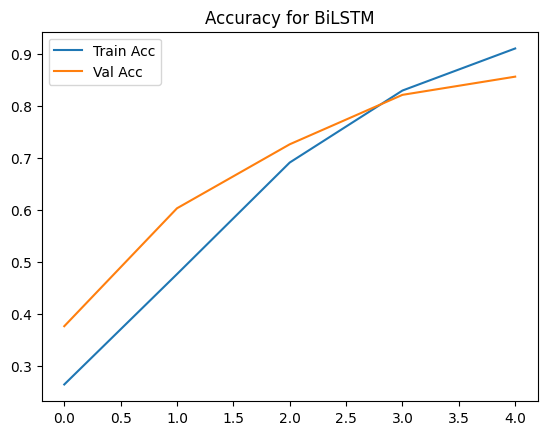

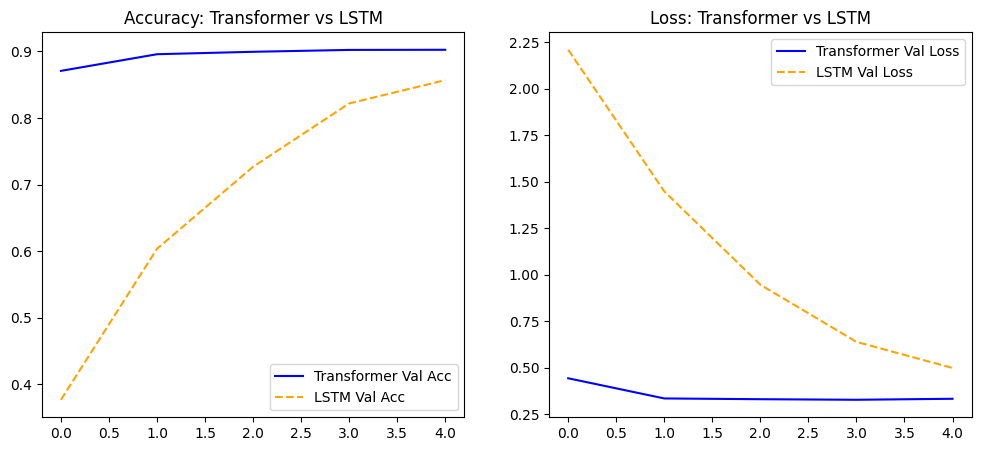

In [13]:
plot_history(h_trans, "Transformer")
plot_history(h_lstm, "BiLSTM")
compare_histories(h_trans, h_lstm)

## Inspect one example prediction

In [14]:
predict_example(transformer_model, vocab, raw_data, encoded, MAX_LEN, index=15)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

Example Sentence: this willingness is the main difference in the number of bombings in the south as opposed to the center - north of the country . )
WORD            | TRUE       | PRED
----------------------------------------
this            | DET        | DET ✅
willingness     | NOUN       | NOUN ✅
is              | AUX        | AUX ✅
the             | DET        | DET ✅
main            | ADJ        | ADJ ✅
difference      | NOUN       | NOUN ✅
in              | ADP        | ADP ✅
the             | DET        | DET ✅
number          | NOUN       | NOUN ✅
of              | ADP        | ADP ✅
bombings        | NOUN       | NOUN ✅
in              | ADP        | ADP ✅
the             | DET        | DET ✅
south           | NOUN       | NOUN ✅
as              | SCONJ      | ADP ❌
opposed         | VERB       | VERB ✅
to              | ADP        | PART ❌
the             | DET        | DET ✅
center          | NOUN       | NOUN ✅
-               | PUNCT 

## Attention map

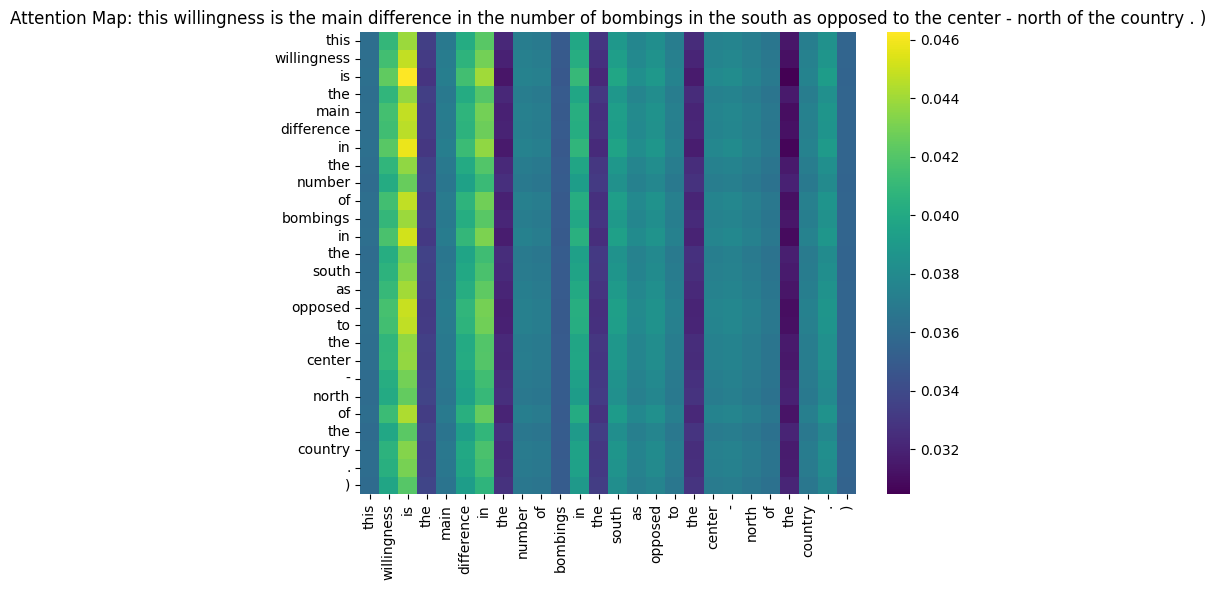

In [15]:
plot_attention_map(transformer_model, vocab, raw_data, encoded, MAX_LEN, index=15)

## Confusion matrix

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


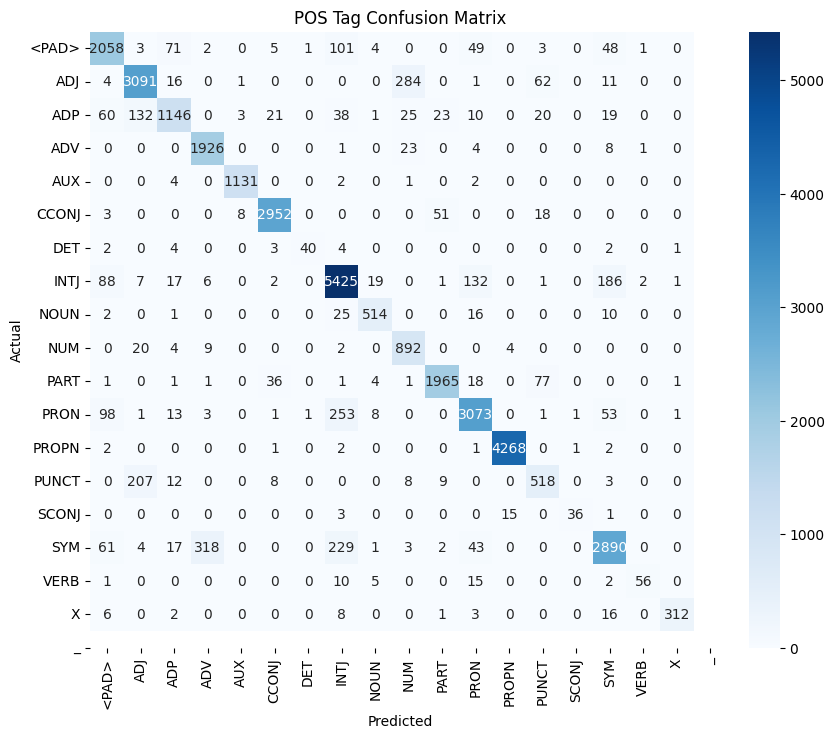

In [16]:
plot_confusion_matrix(transformer_model, X, y, vocab)

## Quantitative comparison

In [17]:
compare_models_metrics(transformer_model, lstm_model, X, y)


Model Comparison
--------------------------------------------------
Metric       | Transformer  | LSTM
--------------------------------------------------
Accuracy     | 0.9070       | 0.9088
Precision    | 0.9088       | 0.9078
Recall       | 0.9070       | 0.9088
F1 Score     | 0.9065       | 0.9028


/home/dan-gavriluta/Coding/ml-project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Accuracy per tag

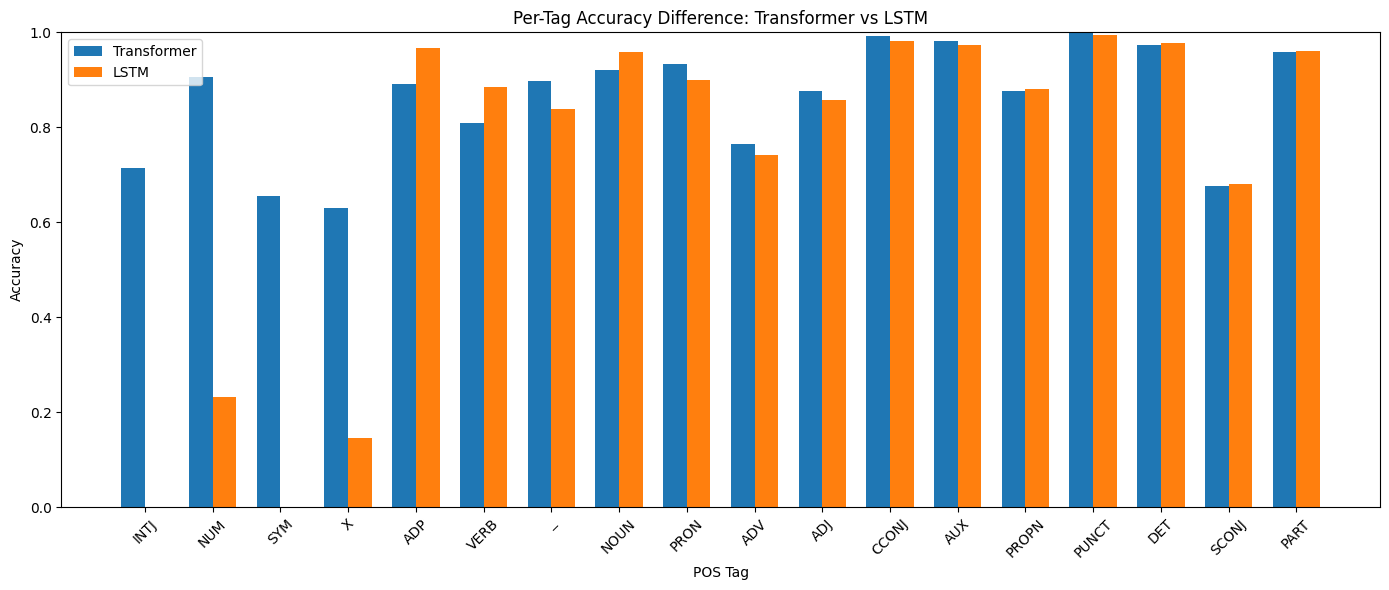

In [18]:
# compare_tag_accuracy(transformer_model, lstm_model, X, y, vocab)
compare_tag_accuracy_sorted(transformer_model, lstm_model, X, y, vocab)

## Sentence accuracy

In [19]:
compare_sentence_accuracy(transformer_model, lstm_model, X, y)


Sentence-Level Accuracy Comparison
------------------------------------------------------------
Model           | Correct Sentences    | Accuracy
------------------------------------------------------------
Transformer     | 675                  | 0.3375 (33.75%)
LSTM            | 622                  | 0.3110 (31.10%)


##  Compare Transformer and LSTM on the same test (not training like before!) set

In [20]:
results = evaluate_models_on_test_set(
    transformer_model,
    lstm_model,
    X_test,
    y_test,
    vocab
)


Overall Test Set Comparison
--------------------------------------------------------------------------------
Metric               | Transformer     | LSTM           
--------------------------------------------------------------------------------
Token Accuracy       | 0.8300          | 0.8617         
Precision            | 0.8291          | 0.8621         
Recall               | 0.8300          | 0.8617         
F1 Score             | 0.8278          | 0.8547         
Sentence Accuracy    | 0.1450          | 0.1800         

Per-Tag Accuracy
--------------------------------------------------------------------------------
Tag          | Transformer  | LSTM         | Diff (T-L)  
--------------------------------------------------------------------------------
ADJ          | 0.6786       | 0.7031       | -0.0246     
ADP          | 0.8931       | 0.9473       | -0.0542     
ADV          | 0.6688       | 0.6433       | +0.0255     
AUX          | 0.9838       | 0.9704       | +0.0135   

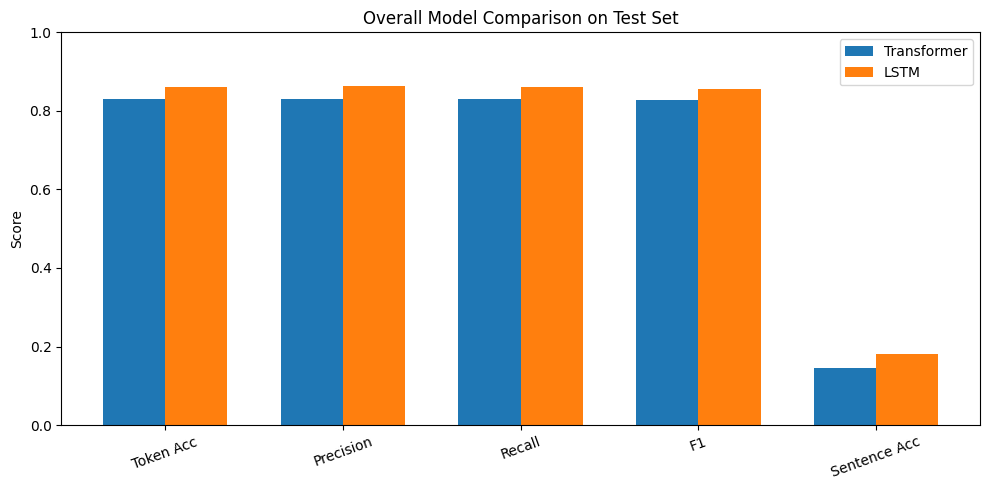

In [21]:
def plot_overall_metric_comparison(results):
    metrics = ["token_accuracy", "precision", "recall", "f1", "sentence_accuracy"]
    trans_values = [results["transformer"][m] for m in metrics]
    lstm_values = [results["lstm"][m] for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, trans_values, width, label="Transformer")
    plt.bar(x + width/2, lstm_values, width, label="LSTM")

    plt.xticks(x, ["Token Acc", "Precision", "Recall", "F1", "Sentence Acc"], rotation=20)
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title("Overall Model Comparison on Test Set")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_overall_metric_comparison(results)